№

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from metric import precision_at_recall
from catboost import CatBoostClassifier
import shap


/Users/danasokol/Desktop/ML - соревы/Classification_of_bots/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


___
# **Данные**

In [4]:
#Загрузка
metadata_dates = [
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
]

train = pd.read_csv("data/train.csv", parse_dates=metadata_dates)
test = pd.read_csv("data/test.csv", parse_dates=metadata_dates)
events = pd.read_csv("data/events.csv.gz", parse_dates=["event_ts"])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4)) 

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


### **Агрегация по признакам только внутри окна**

<div style="line-height: 1.8;">

Признаки считаем только по событиям внутри окна: window_start_ts <= event_ts < window_end_ts. Это требование из условия, а не рекомендация.

In [5]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id', how = 'inner', validate = 'many_to_one')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print("События train внутри окна:", len(ev_tr))
print("События test внутри окна:", len(ev_te))

События train внутри окна: 198436
События test внутри окна: 89690


In [6]:
#Дубликаты

event_columns = events.columns.to_list()

dubl_train = ev_tr.duplicated(subset = event_columns).sum()
dubl_test = ev_te.duplicated(subset = event_columns).sum()

print("Дубликаты train:", dubl_train)
print("Дубликаты test:", dubl_test)

ev_tr = ev_tr.drop_duplicates(subset = event_columns).copy()
ev_te = ev_te.drop_duplicates(subset = event_columns).copy()

print(f'Осталось в трейне: {len(ev_tr)}')
print(f'Осталось в тесте: {len(ev_te)}')


Дубликаты train: 2952
Дубликаты test: 1341
Осталось в трейне: 195484
Осталось в тесте: 88349


In [7]:
'''
Всё в нижний регистр,
"WEB", "Web", "desktop"  в "web";
"ANDROID", "Android"  в "android";
"IOS", "iOS", "iphone" в "ios".
'''

for ev in (ev_tr, ev_te):
    ev['platform_norm'] = (
        ev['platform'].astype('string').str.strip()
        .str.lower()
        .replace({
            'desktop' : 'web',
            'iphone' : 'ios',
            "" : pd.NA,
        })
    )
print(ev_tr['platform_norm']. value_counts(dropna = False))

platform_norm
web        108382
android     76826
ios         10276
Name: count, dtype: Int64


____
# **Feature engineering research**

## **Эксперимент №1. Временные признаки**



<div style="line-height: 1.5;">

В качестве исходной точки оставим два признака от составителей - общее число событий **n_events** и число уникальных объявлений **item_nunique**. Первый характеризует общий объём активности cookie, второй показывает, со сколькими разными объявлениями она взаимодействовала.

In [68]:
#Базовые признаки
def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g.item_id.nunique(),
    })
    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    return f.fillna(0)

Xtr = basic_features(ev_tr, train)

Xte = basic_features(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,n_events,item_nunique
0,ck_54a059eb7d3ea68b,7,4
1,ck_7e4de46eeab82974,41,19
2,ck_9320229ef6304522,36,19
3,ck_30ccd25bc1714ed9,21,10
4,ck_a77c5f05948cdeef,28,16


### **ML part (catboost only)**
<div style="line-height: 1.8;">

В данном части мы в основном сосредоточимся на валидации полученных признаков. В качестве модели для валидации используем **CatBoostClassifier** без дополнительной настройки гиперпараметров. Качество сравниваем по **precision_at_recall**.  Обязательно используем **Shap Explainer** для интерпритации

In [17]:
def train_catboost(final_tr, train, cat_cols = None):

    cols = final_tr.columns.drop('cookie_id')

    is_valid = train['window_start_ts'].ge('2026-04-17').values

    X_train = final_tr.loc[~is_valid, cols]
    X_valid = final_tr.loc[is_valid, cols]

    y_train = train.loc[~is_valid, 'target']
    y_valid = train.loc[is_valid, 'target']

    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        random_seed=0,
        verbose=False
    )

    if cat_cols is None:
        model.fit(X_train, y_train)
    else:
        model.fit(
            X_train,
            y_train,
            cat_features=cat_cols
        )

    p_valid = model.predict_proba(X_valid)[:, 1]

    print('P@R0.7 на валидации:', round(precision_at_recall(y_valid, p_valid), 4))
    print('доля ботов (это уровень константы):', round(y_valid.mean(), 4))

    return model, X_train, X_valid, y_train, y_valid, p_valid

Зафиксируем данное значение в качестве **baseline**

In [74]:
coords = train_catboost(Xtr, train)

P@R0.7 на валидации: 0.1171
доля ботов (это уровень константы): 0.082


**baseline**: P@R0.7 на валидации: 0.1171

<div style="line-height: 1.8;">

 Для каждой куки сортируем события по времени и считаем интервал между соседними событиями. Новый столбец назовём **gap_s**. Отдельно сохраняем **within_gap_s**. Интервалы больше 30 минут считаем границей между периодами активности (в дальнейшем будем называть это **сессией**) и исключаем из **внутрисессионной** статистики. Порог 30 минут здесь используется как начальное правило (по сути взят из головы) и в дальнейшем может быть проверен отдельно

In [9]:
#Добавим гэп по времени: Если между соседними действиями одной куки прошло больше 30 минут, то это новая сессия

gap = 1800 #секунд (30 минут) - Граница между сессиями

#Отсортируем куки по времени
for ev in (ev_tr, ev_te):
    ev.sort_values(
        ["cookie_id", "event_ts"],
        kind="stable",
        inplace=True,
    )

    #Гэпы в течение всего времени 
    ev["gap_s"] = (
        ev.groupby("cookie_id", sort=False)["event_ts"]
        .diff()
        .dt.total_seconds()
    )

    #Гэпы в течение одной сессии
    ev["within_gap_s"] = ev["gap_s"].where(
        ev["gap_s"] <= gap
    )

In [10]:
#Проверка гипотезы: средний гэп мужду активностями у людей больше, чем ботов
median_gap = (
    ev_tr.groupby('cookie_id', as_index=False)
    .agg (median_gap_s = ('gap_s', 'median'))
)
print(median_gap)

median_gap_plus_target = median_gap.merge(
    train[['cookie_id', 'target']],
    on = 'cookie_id',
    how = 'left',
    validate='one_to_one'
)
print(median_gap_plus_target)

median_gap_plus_target. groupby('target')['median_gap_s'].median()

                 cookie_id  median_gap_s
0      ck_000c95f1408dcb00          58.0
1      ck_000e8c52636e3bec          23.0
2      ck_0010e31baa4a1fb7         334.0
3      ck_0010ec3874fb5378          32.0
4      ck_001722063b94cae0         175.0
...                    ...           ...
11086  ck_ffe2bdd663cea9ac          69.0
11087  ck_ffe648839179d098         147.0
11088  ck_ffee36a37e2532f5          24.0
11089  ck_fff88a7920fd0fb6          66.0
11090  ck_fffa4b3ab0203fcf          84.5

[11091 rows x 2 columns]
                 cookie_id  median_gap_s  target
0      ck_000c95f1408dcb00          58.0       0
1      ck_000e8c52636e3bec          23.0       0
2      ck_0010e31baa4a1fb7         334.0       0
3      ck_0010ec3874fb5378          32.0       0
4      ck_001722063b94cae0         175.0       0
...                    ...           ...     ...
11086  ck_ffe2bdd663cea9ac          69.0       0
11087  ck_ffe648839179d098         147.0       0
11088  ck_ffee36a37e2532f5          24.0 

target
0    60.5
1    25.0
Name: median_gap_s, dtype: float64

<div style="line-height: 1.8;">

Как видно из теста, гипотеза подтверждается. **Медианный интервал между действиями людей почти в 2,5 раза больше, чем для ботов**. Значит, временная структура активности содержит сигнал, который имеет смысл использовать при построении признаков. Спасибо большое, составители, за подсказку!

Исходя из этого, двигаем в сторону инжениринга признаков **"скоростной группы"**. Добавляем среднее, квантили (p10-p90), стандартное отклонение и число доступных интервалов. 

Те же характеристики отдельно считаем для **within_gap_s**, то есть без длинных пауз между **сессиями**. Для оценки регулярности используем **коэффициент вариации std / mean** для обеих групп (**cv_gap_s**, **cv_within_gap_s**)

In [11]:
def time_features(ev, meta):

    '''
    Временные признаки.
    Данная функция берёт в основу gap_s и within_gap_s для разных масштабов
    Признаки: 
    -Среднее;
    -Медиана;
    -Количество;
    -Стандартное отклонение;
    -p10 - p90 интервалы;
    -Внутрисессионные показетели
    '''
    f = (
        ev.groupby('cookie_id')
        .agg(
            n_intervals=('gap_s', 'count'),
            mean_gap_s=('gap_s', 'mean'),
            median_gap_s=('gap_s', 'median'),
            p10_gap_s=('gap_s', lambda x: x.quantile(0.10)),
            p25_gap_s=('gap_s', lambda x: x.quantile(0.25)),
            p75_gap_s=('gap_s', lambda x: x.quantile(0.75)),
            p90_gap_s=('gap_s', lambda x: x.quantile(0.90)),
            std_gap_s=('gap_s', 'std'),
            #Внутрисессионные показатели
            n_within_intervals = ('within_gap_s', 'count'),
            mean_within_gap_s = ('within_gap_s', 'mean'),
            median_within_gap_s = ('within_gap_s', 'median'),
            std_within_gap_s = ('within_gap_s', 'std')
        )
    )
    # Коэффициенты вариации
    f['cv_gap_s'] = (
        f['std_gap_s'] /
        f['mean_gap_s'].replace(0, np.nan)
    )

    f['cv_within_gap_s'] = (
        f['std_within_gap_s'] /
        f['mean_within_gap_s'].replace(0, np.nan)
    )

    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    return f

In [12]:
time_tr = time_features(ev_tr, train)
time_te = time_features(ev_te, test)

<div style="line-height: 1.8;">

Дополнительно проверим признаки, которые напрямую описывают долю очень быстрых действий. Для каждой куки считаем долю интервалов не больше 1, 5 и 10 секунд. Во много - это частично пересекается по смыслу с квантилями, но возможно, данный шаг будет полезен для моделей.

In [13]:
def short_gap_features(ev):
    f = (
        ev.groupby('cookie_id')
        .agg(
            share_gap_le_1s = ('gap_s', lambda x: (x.dropna() <= 1).mean()),
            share_gap_le_5s = ('gap_s', lambda x: (x.dropna() <= 5).mean()),
            share_gap_le_10s = ('gap_s', lambda x: (x.dropna() <= 10).mean())
        ).reset_index()
    )
    return f

short_gap_tr = short_gap_features(ev_tr)
short_gap_te = short_gap_features(ev_te)

In [14]:
# Для объединения кучи разных датафреймов
def merge_dataframes(data: list) -> pd.DataFrame:
    result = data[0]
    for i in range(1, len(data)):
        result = result.merge(data[i], on = 'cookie_id' , how = 'left')
    return result

In [15]:
final_tr = merge_dataframes([time_tr,Xtr, short_gap_tr])

In [16]:
final_tr

,cookie_id,n_intervals,mean_gap_s,median_gap_s,p10_gap_s,p25_gap_s,p75_gap_s,p90_gap_s,std_gap_s,n_within_intervals,mean_within_gap_s,median_within_gap_s,std_within_gap_s,cv_gap_s,cv_within_gap_s,n_events,item_nunique,share_gap_le_1s,share_gap_le_5s,share_gap_le_10s
0,ck_54a059eb7d3ea68b,6,27.833333,21.0,3.5,9.50,31.00,59.0,29.949402,6,27.833333,21.0,29.949402,1.076026,1.076026,7,4,0.166667,0.166667,0.333333
1,ck_7e4de46eeab82974,40,986.900000,57.5,6.9,19.00,82.25,3889.7,2416.286861,34,46.617647,50.5,31.594989,2.448360,0.677747,41,19,0.000000,0.075000,0.200000
2,ck_9320229ef6304522,35,1042.600000,22.0,4.8,14.50,73.00,4513.4,2306.449400,29,83.310345,21.0,295.590946,2.212209,3.548070,36,19,0.028571,0.114286,0.171429
3,ck_30ccd25bc1714ed9,20,861.050000,54.5,17.9,37.25,70.00,877.9,2502.081501,18,49.500000,52.0,26.535769,2.905849,0.536076,21,10,0.000000,0.000000,0.050000
4,ck_a77c5f05948cdeef,27,707.333333,52.0,28.6,32.50,106.50,2743.2,1748.439172,24,132.291667,46.5,332.913160,2.471874,2.516509,28,16,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11086,ck_2256c19bb847dd0e,6,1224.666667,25.5,8.0,15.25,58.25,3640.5,2934.246729,5,26.800000,19.0,24.913852,2.395955,0.929621,7,2,0.000000,0.166667,0.166667
11087,ck_ba2e403201cba06d,5,1043.800000,69.0,27.4,55.00,234.00,3004.8,2130.547746,4,91.750000,62.0,98.235686,2.041146,1.070689,6,2,0.000000,0.000000,0.200000
11088,ck_2f43054a1f52b9a2,19,400.052632,126.0,7.8,43.00,254.00,579.6,929.798334,18,197.555556,113.0,300.755563,2.324190,1.522385,20,13,0.052632,0.052632,0.157895
11089,ck_354f57a870e41ddd,5,52.800000,57.0,17.6,29.00,81.00,84.6,33.093806,5,52.800000,57.0,33.093806,0.626777,0.626777,6,1,0.000000,0.000000,0.200000


In [18]:
model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(final_tr, train, cat_cols = None)

P@R0.7 на валидации: 0.3445
доля ботов (это уровень константы): 0.082


### **Shape Explainer**

Background dataset has 9140 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=9140 when initializing the masker.
 99%|===================| 1924/1951 [00:26<00:00]        

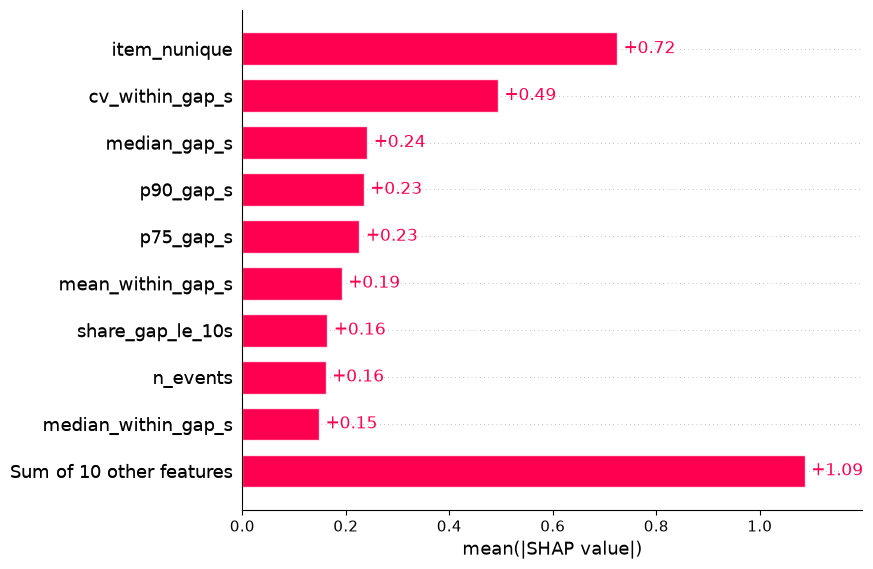

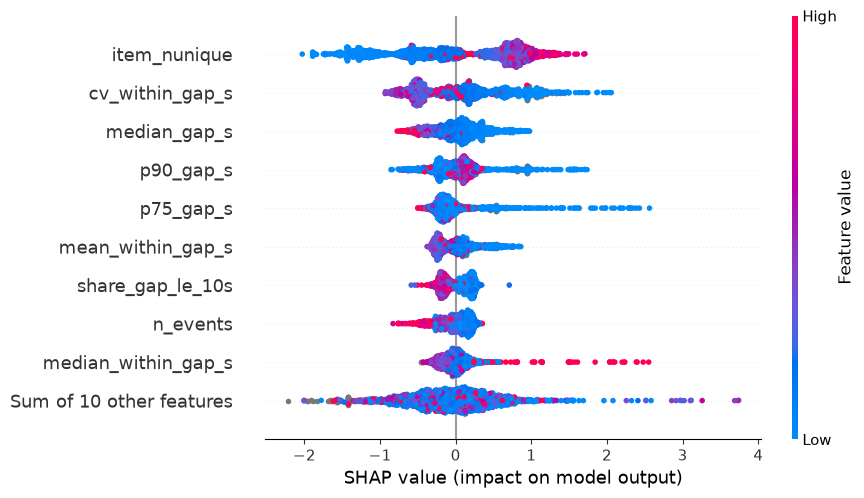

In [19]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_valid)
shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

<div style="line-height: 1.8;">

Посмотрим **SHAP dependence plot** для трёх разных по смыслу признаков (по глобальному смыслу). 

**item_nunique** - признак объёма; 

**cv_within_gap_s** - признак регулярности; 

**share_gap_le_10s** - признак скорости.

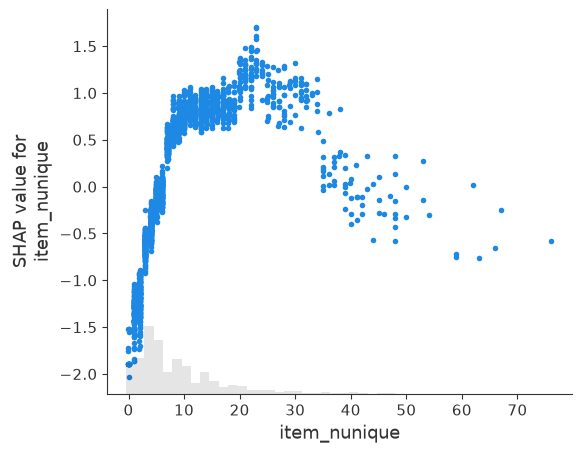

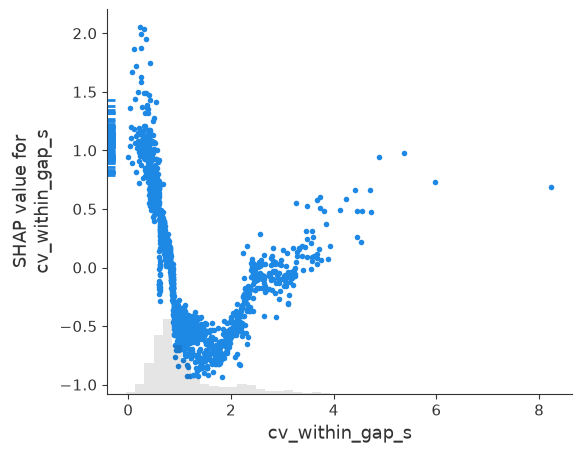

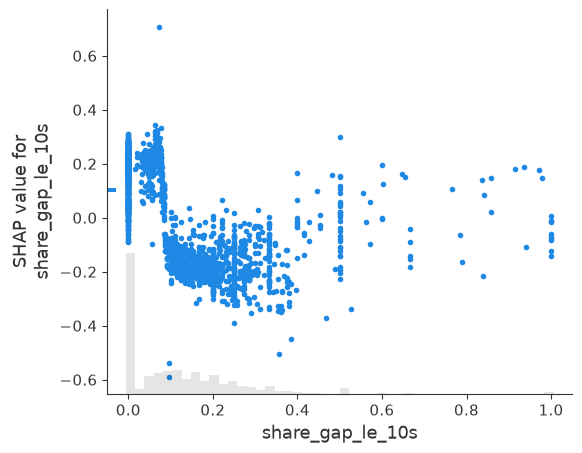

In [20]:
#Графики зависимости  признака от 
features = [
    "item_nunique",
    "cv_within_gap_s",
    "share_gap_le_10s"
]

for feature in features:
    shap.plots.scatter(shap_values[:, feature])

### **Корреляционная матрица**
<div style="line-height: 1.8;">

Несколько наиболее важных признаков по shap построены из одного распределения временных интервалов. Их корреляция между собой достаточно интуитивна, но посмотрим на числовые значения. Для проверки используем корреляцию Спирмена.

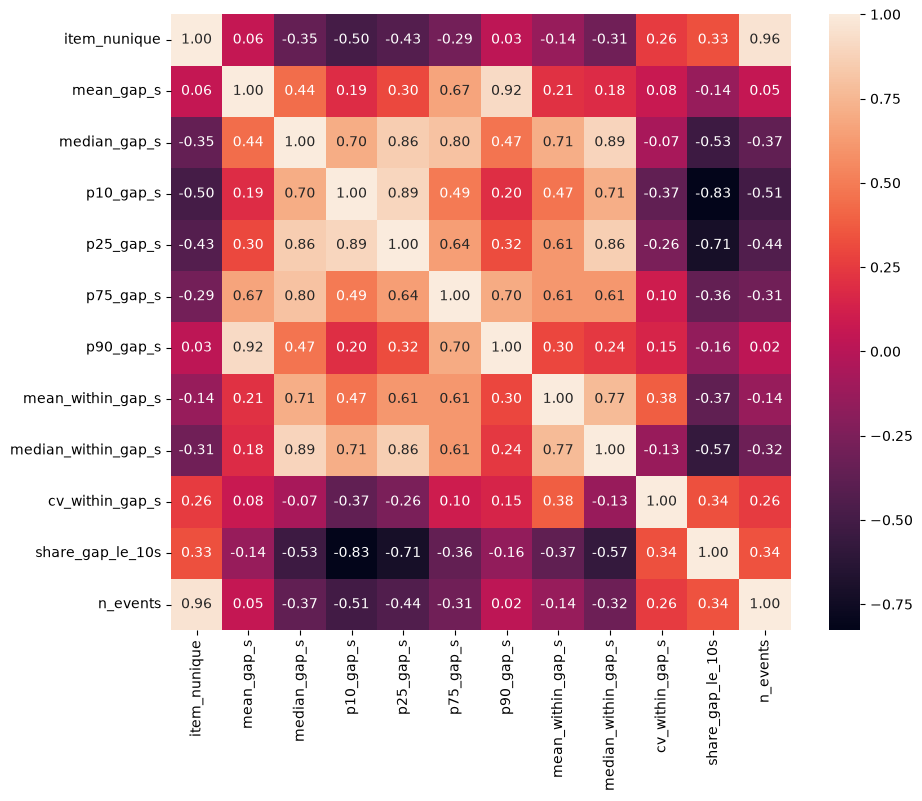

In [21]:
#Корреляция Спирмана
corr_cols = [
    'item_nunique',
    'mean_gap_s',
    'median_gap_s',
    'p10_gap_s',
    'p25_gap_s',
    'p75_gap_s',
    'p90_gap_s',
    'mean_within_gap_s',
    'median_within_gap_s',
    'cv_within_gap_s',
    'share_gap_le_10s',
    'n_events'
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_tr[corr_cols].corr(method='spearman'),
    annot=True,
    fmt='.2f'
)

plt.show()

<div style="line-height: 1.8;">

Матрица показывает выраженную группу **признаков скорости**, что было достаточно очевидно. Видно, что **mean_gap_s** и **p90_gap_s** имеют корреляцию 0.92, **p10_gap_s** и **p25_gap_s** 0.89 и т.д.
Высокая корреляция сама по себе не требует удалять признаки из CatBoost, т.к. деревья способны работать с зависимыми между собой переменными. Но мы сами формируем признаки, поэтому нет смысла раздувать признаковое пространство без причины. 

----
## **Эксперимент №2**.

**Сравнивним полный набор с более компактным**. В каждой группе оставляем несколько признаков с разным смыслом: общая и внутрисессионная скорость, быстрый и медленный хвост распределения, регулярность, общий объём активности (**n_events**) и разнообразие объявлений (**item_nunique**).

In [22]:
colls = [
    'cookie_id',
    'median_gap_s',
    'p10_gap_s',
    'p90_gap_s',
    'cv_within_gap_s',
    'mean_within_gap_s',
    'n_events',
    'item_nunique',
]

final_tr = final_tr[colls].copy()
final_tr.head(5)

,cookie_id,median_gap_s,p10_gap_s,p90_gap_s,cv_within_gap_s,mean_within_gap_s,n_events,item_nunique
0,ck_54a059eb7d3ea68b,21.0,3.5,59.0,1.076026,27.833333,7,4
1,ck_7e4de46eeab82974,57.5,6.9,3889.7,0.677747,46.617647,41,19
2,ck_9320229ef6304522,22.0,4.8,4513.4,3.548070,83.310345,36,19
3,ck_30ccd25bc1714ed9,54.5,17.9,877.9,0.536076,49.500000,21,10
4,ck_a77c5f05948cdeef,52.0,28.6,2743.2,2.516509,132.291667,28,16


In [23]:
model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(final_tr, train, cat_cols = None)

P@R0.7 на валидации: 0.4043
доля ботов (это уровень константы): 0.082


##### Качество CatBoost выросло почти на **20% относительно модели со всей сборкой**. :)

<div style="line-height: 1.8;">

Для дальнейших экспериментов будем использовать компактные наборы, **значительно**  отличающиеся по смыслу. Да, возможно это было и так очевидно, но проверить надо было. Мы же учёные, всё такое)

----

## **Эксперимент №3. Сессии**

<div style="line-height: 1.8;">

Данный эксперимен посвящён развитию идее **сессий**. До этого, мы использовали признаки скорости, они коррелировали между собой и мы половину выбросили. **Сессии** продолжают идею использовать время, как крайне важный маркер, но немного по-другому. Поднимем вопрос: **Как суточная активность куки разбита на  периоды работы?** То есть, оценим - равномерное распределение активности или нет? 
Для начала возьмём следующий набор признаков:

    - n_sessions                 количество сессий
    - largest_session_share      концентрация активности (какая доля всех событий пришлась на самую крупную сессию)
    - median_session_size        интенсивность одной сессии (сколько событиый за сессию медианно)
    - median_session_duration  продолжительность одной сессии



In [24]:
#Считаем данные признаки бейзлайном

base_features = [
    'median_gap_s',        
    'p10_gap_s',           
    'p90_gap_s',           
    'cv_within_gap_s',     # регулярность
    'mean_within_gap_s',   
    'n_events',            # объём активности
    'item_nunique',        # разнообразие объявлений
]

In [25]:
gap = 1800 #тот же порог в 30 минут

for ev in (ev_tr, ev_te):

    #Булево значение. Либо первый гэп, который nan, либо тот, что больше 30 минут
    ev['new_session'] = (
        ev['gap_s'].isna() | (ev['gap_s'] > gap)) 
    
    ev['session_id'] = (
        ev.groupby('cookie_id')['new_session'].cumsum() 
    )

ev_tr.head(1)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,...,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts,platform_norm,gap_s,within_gap_s,new_session,session_id
189443,ck_000c95f1408dcb00,2026-04-19 14:49:54,100,search_results_view,Web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,hobbi,NaN,NaN,...,2.0,373.0,1059.0,2026-04-19,2026-04-20,web,NaN,NaN,True,1


In [26]:
def session_features(ev):
    '''
    - n_sessions                 количество сессий
    - largest_session_share      концентрация активности (какая доля всех событий пришлась на самую крупную сессию)
    - median_session_size        интенсивность одной сессии (сколько событиый за сессию медианно)
    - median_session_duration  продолжительность одной сессии
    
    '''

    sessions = (
        ev.groupby(['cookie_id', 'session_id'])
        .agg(
            session_size=('event_ts', 'size'),
            session_start=('event_ts', 'min'),
            session_end=('event_ts', 'max'),
        ).reset_index()
    )

    sessions['session_duration'] = (sessions['session_end'] - sessions['session_start']).dt.total_seconds()

    f = (
        sessions.groupby('cookie_id')
        .agg(
            n_sessions=('session_id', 'count'),
            median_session_size=('session_size', 'median'),
            median_session_duration=('session_duration', 'median'),
            max_session_size=('session_size', 'max'),
        ).reset_index()
    )

    n_events = (
        ev.groupby('cookie_id').size()
        .rename('n_events').reset_index()
    )

    f = f.merge(n_events, on='cookie_id', how='left', validate='one_to_one')

    f['largest_session_share'] = (f['max_session_size']/ f['n_events'])

    f = f.drop(columns=['max_session_size','n_events']
    )

    return f

In [27]:
session_tr = session_features(ev_tr)
session_te = session_features(ev_te)

In [28]:
session_tr.head() 

,cookie_id,n_sessions,median_session_size,median_session_duration,largest_session_share
0,ck_000c95f1408dcb00,6,2.0,21.5,0.437500
1,ck_000e8c52636e3bec,2,17.0,1212.0,0.882353
2,ck_0010e31baa4a1fb7,8,1.5,51.5,0.250000
3,ck_0010ec3874fb5378,11,7.0,222.0,0.189189
4,ck_001722063b94cae0,1,15.0,4118.0,1.000000


In [29]:
final_tr = final_tr.merge(session_tr, on='cookie_id', how='left')


In [30]:
final_tr.shape

(11091, 12)

In [31]:
model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(final_tr, train, cat_cols = None)

P@R0.7 на валидации: 0.3823
доля ботов (это уровень константы): 0.082


##### -> **Сессионные признаки в текущем виде качество не улучшили**.

____
## **Эксперимент №4. Технический контекст**

<div style="line-height: 1.8;">
Данный эксперимент посвящён идее влияния технического контекста. Признаки данной группы отвечают на вопрос: "С какого устройства и программного окружения действует куки?Возьмём основную платформу и User-Agent, а также количество различных платформ и User-Agent внутри окна

In [32]:
#Для опередения "самой частой"
def mode_or_unknown(x):
    x = x.dropna()
    if len(x) == 0:
        return 'unknown'

    return x.value_counts().idxmax()

#Технический контекст
def technical_features(ev, meta):
    '''
    main_user_agent - основная платформа для данной куки
    main_user_agent - основное устройство или браузер для данной куки
    n_platforms  - общее количество платформ
    n_user_agents - общее количество устройств
    '''
    f = (ev.groupby('cookie_id') 
        .agg( 
            main_platform=('platform_norm', mode_or_unknown), 
            main_user_agent=('user_agent', mode_or_unknown),
            n_platforms=('platform_norm', 'nunique'),
            n_user_agents=('user_agent', 'nunique'),
        )
        .reset_index()
    )

    f = meta[['cookie_id']].merge(f, on='cookie_id', how='left', validate='one_to_one')

    f['main_platform'] = (f['main_platform'].fillna('unknown').astype(str))

    f['main_user_agent'] = (f['main_user_agent'] .fillna('unknown').astype(str)    )

    return f

technical_tr = technical_features(ev_tr, train)
technical_te = technical_features(ev_te, test)

<div style="line-height: 1.8;">

**Отдельно сформируем признаки по объявлениям**. Используем самую частую **категорию** и **локацию**, а также число уникальных категорий и локаций. В отличие от
**item_nunique** разнообразие областей, между которыми перемещается пользователь.

In [33]:
#Такая же логика по признакам, что и в technical_features, только теперь для категорий и локаций
def content_features(ev, meta):
    f = (
        ev.groupby('cookie_id')
        .agg(
            main_item_category=('item_category', mode_or_unknown),
            main_item_location=('item_location', mode_or_unknown),

            item_category_nunique=('item_category', 'nunique'),
            item_location_nunique=('item_location', 'nunique'),
        )
        .reset_index()
    )

    f = meta[['cookie_id']].merge(f, on='cookie_id', how='left', validate='one_to_one')
    f['main_item_category'] = (f['main_item_category'].fillna('unknown').astype(str))
    f['main_item_location'] = (f['main_item_location'].fillna('unknown').astype(str))

    return f

In [34]:
content_tr = content_features(ev_tr, train)
content_te = content_features(ev_te, test)

##### Построим два датасета - **технический и контентный**, склеив их с базовыми утверждёнными признаками

In [35]:
base_cols = [
    'median_gap_s',
    'p10_gap_s',
    'p90_gap_s',
    'cv_within_gap_s',
    'mean_within_gap_s',
    'n_events',
    'item_nunique',
]

#Базовый
base_tr = final_tr[['cookie_id'] + base_cols].copy()

#Технический
tech_final_tr = base_tr.merge(
    technical_tr,
    on='cookie_id',
    how='left',
    validate='one_to_one'
)

#Контентный
content_final_tr = base_tr.merge(
    content_tr,
    on='cookie_id',
    how='left',
    validate='one_to_one'
)

In [ ]:
#Технический
cat_cols = [
    'main_platform',
    'main_user_agent'
]

model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(tech_final_tr, train, cat_cols = cat_cols)

P@R0.7 на валидации: 0.4431
доля ботов (это уровень константы): 0.082


In [ ]:
#Контентный
cat_cols = [
    'main_item_category',
    'main_item_location'
]

model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(content_final_tr, train, cat_cols = cat_cols)

P@R0.7 на валидации: 0.5022
доля ботов (это уровень константы): 0.082


In [38]:
#Cмесь: технический + контентный 
final_final_tr = (
    base_tr
    .merge(technical_tr, on='cookie_id', how='left', validate='one_to_one')
    .merge(content_tr, on='cookie_id', how='left', validate='one_to_one')
)


In [ ]:
#Cмесь: технический + контентный 
cat_cols = [
    'main_item_category',
    'main_item_location',
    'main_platform',
    'main_user_agent'
]

model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(final_final_tr, train, cat_cols = cat_cols)


P@R0.7 на валидации: 0.5068
доля ботов (это уровень константы): 0.082


### **Shape Explainer**

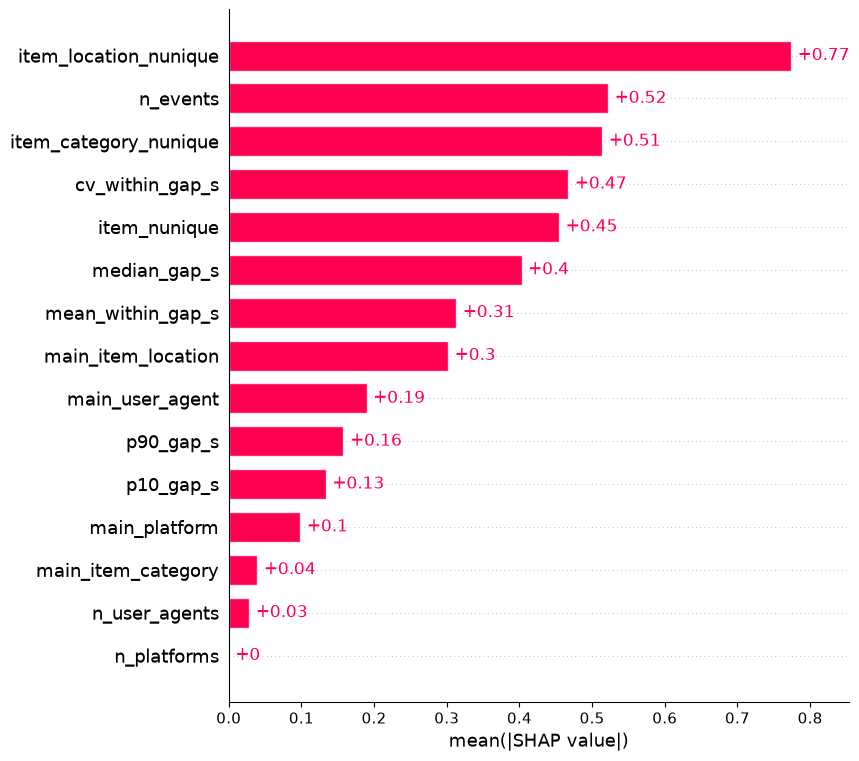

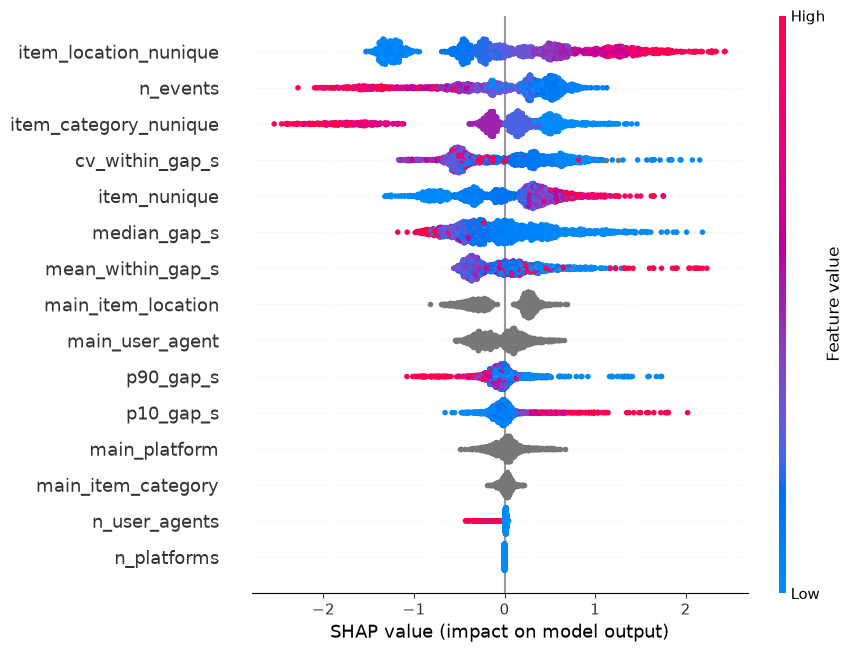

In [ ]:
# Считаем SHAP на validation
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_valid)

shap.plots.bar(
    shap_values,
    max_display=20
)
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

**n_platforms**, **n_user_agents** и **main_item_category** оказались ненужны по Shape validation. shape_values < 0.1

In [41]:
drop_cols = [
    'n_platforms',
    'n_user_agents',
    'main_item_category'
]

final_2 = final_final_tr.drop(columns=drop_cols)
final_2

,cookie_id,median_gap_s,p10_gap_s,p90_gap_s,cv_within_gap_s,mean_within_gap_s,n_events,item_nunique,main_platform,main_user_agent,main_item_location,item_category_nunique,item_location_nunique
0,ck_54a059eb7d3ea68b,21.0,3.5,59.0,1.076026,27.833333,7,4,android,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,sankt-peterburg,3,5
1,ck_7e4de46eeab82974,57.5,6.9,3889.7,0.677747,46.617647,41,19,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,vladivostok,1,12
2,ck_9320229ef6304522,22.0,4.8,4513.4,3.548070,83.310345,36,19,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,novosibirsk,7,9
3,ck_30ccd25bc1714ed9,54.5,17.9,877.9,0.536076,49.500000,21,10,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,cheboksary,1,4
4,ck_a77c5f05948cdeef,52.0,28.6,2743.2,2.516509,132.291667,28,16,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,ekaterinburg,4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11086,ck_2256c19bb847dd0e,25.5,8.0,3640.5,0.929621,26.800000,7,2,android,Avito/120.0 (Android 13; M2101K6G) okhttp/4.11.0,makhachkala,4,3
11087,ck_ba2e403201cba06d,69.0,27.4,3004.8,1.070689,91.750000,6,2,android,Avito/122.0 (Android 13; SM-A515F) okhttp/4.11.0,ekaterinburg,1,1
11088,ck_2f43054a1f52b9a2,126.0,7.8,579.6,1.522385,197.555556,20,13,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,tyumen,1,9
11089,ck_354f57a870e41ddd,57.0,17.6,84.6,0.626777,52.800000,6,1,android,Avito/120.0 (Android 11; SM-A125F) okhttp/4.11.0,ulyanovsk,1,2


In [42]:
cat_cols = [
    'main_item_location',
    'main_platform',
    'main_user_agent'
]

model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(final_2, train, cat_cols = cat_cols)


P@R0.7 на валидации: 0.5803
доля ботов (это уровень константы): 0.082


#### Вывод

<div style="line-height: 1.8;">

После сокращения набора P@R0.7 вырос с 0.5359 до 0.5803.
В текущем наборе наиболее полезными категориальными характеристиками оказались **разнообразие локаций и категорий объявлений**, **основная локация**, **User-Agent и платформа**.

____
## **Эксперимент №5. Посмотрим на event_name**

In [43]:
ev_tr['event_name'].value_counts()

event_name
item_view               73186
search_results_view     60806
photo_swipe             22608
favorite_add            11843
seller_page_view        10550
contact_phone_show       6961
login                    3848
contact_chat_open        3736
contact_message_sent     1946
Name: count, dtype: int64

<div style="line-height: 1.8;">

Для каждой куки посчитаем число встречающихся типов событий и несколько характеристик их распределения. **dominant_event_share** будет показывать, насколько активность сосредоточена на одном типе действий. **share_item_view** и **share_photo_swipe** описывают долю данных событий.

Отдельно добавим **энтропию  распределения event_name**. Низкое значение соответствует более однотипной активности, высокое означает, что события распределены между большим числом типов более равномерно.

In [44]:
def event_structure_features(ev, meta):

    #Подсёт событий (матрица, куки * тип события)
    counts = (
        ev.groupby(['cookie_id', 'event_name']).size()
        .unstack(fill_value = 0)
    )

    total = counts.sum(axis = 1)
    shares = counts.div(total, axis = 0)

    f = pd. DataFrame(index = counts.index)

    f['n_event_type'] = (counts > 0).sum(axis = 1)
    f['dominant_event_share'] = shares.max(axis=1)

    # Просмотр объявления 
    f['share_item_view'] = (
        shares['item_view']
        if 'item_view' in shares.columns
        else 0
    )
    #Cвайп фото
    f['share_photo_swipe'] = (
        shares['photo_swipe']
        if 'photo_swipe' in shares.columns
        else 0
    )
    
    #Энтропия
    f['event_entropy'] = -(shares.where(shares > 0) *np.log(shares.where(shares > 0))).sum(axis=1)

    f = (meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left',validate='one_to_one'))

    return f

In [45]:
even_structure_tr =  event_structure_features(ev_tr, train)
event_struct_te = event_structure_features(ev_te, test)

In [46]:
event_final_tr = final_2.merge(even_structure_tr, on ='cookie_id', how ='left', validate = 'one_to_one')

In [47]:
cat_cols = [
    'main_item_location',
    'main_platform',
    'main_user_agent'
]

model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(event_final_tr, train, cat_cols = cat_cols)


P@R0.7 на валидации: 0.6087
доля ботов (это уровень константы): 0.082


### SHAP Explainer

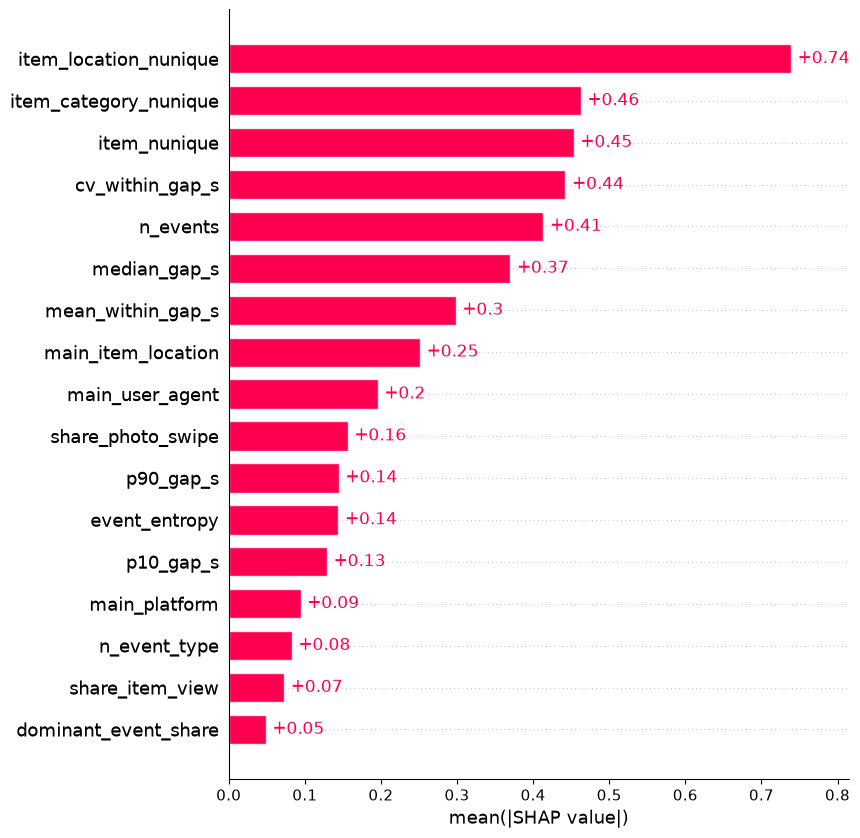

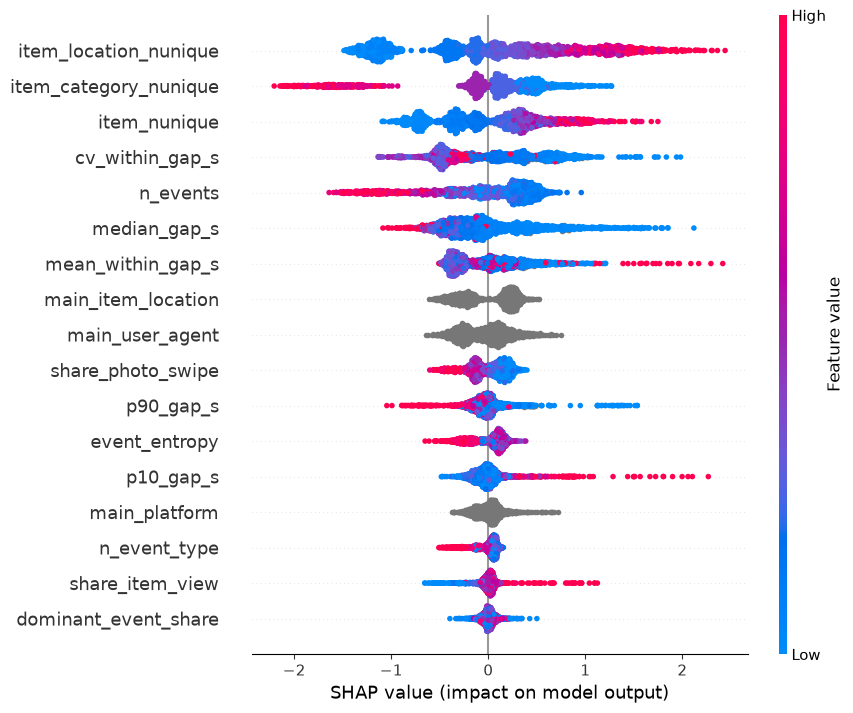

In [48]:
# Считаем SHAP на validation
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_valid)

# Глобальная важность признаков
shap.plots.bar(
    shap_values,
    max_display=20
)
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

____
## **Эксперимент № 6. Доли**

<div style="line-height: 1.8;">

Добавим доли уникальных объектов, локаций и категорий относительно числа событий, а также отношения количества объектов, локаций и категорий друг к другу. Т.к. одинаковое число уникальных значений может иметь разный смысл при разном общем объёме активности

In [50]:
def add_diversity_ratio_features(f):
    f = f.copy()

    # добавим все относительные признаки одновременно
    f['item_unique_share'] = (
        f['item_nunique'] /
        f['n_events'].replace(0, np.nan)
    ) # Насколько разнообразцы объявления

    f['location_unique_share'] = (
        f['item_location_nunique'] /
        f['n_events'].replace(0, np.nan)
    ) #насколько разнообразны локации
    
    f['category_unique_share'] = (
        f['item_category_nunique'] /
        f['n_events'].replace(0, np.nan)
    ) #насколько разнообразны категории товаров среди просмотренных
    
    # сколько локаций приходится на одну категорию
    f['locations_per_category'] = (
        f['item_location_nunique'] /
        f['item_category_nunique'].replace(0, np.nan)
    )

    # Насколько число уникальных locations велико относительно items
    f['locations_per_item'] = (
        f['item_location_nunique'] /
        f['item_nunique'].replace(0, np.nan)
    )

    # Сколько уникальных items приходится на одну локацию
    f['items_per_location'] = (
        f['item_nunique'] /
        f['item_location_nunique'].replace(0, np.nan)
    )

    # Сколько уникальных items приходится на одну категорию
    f['items_per_category'] = (
        f['item_nunique'] /
        f['item_category_nunique'].replace(0, np.nan)
    )
    return f 

In [51]:
ratio_tr = add_diversity_ratio_features(event_final_tr)

In [52]:
model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(ratio_tr, train, cat_cols = cat_cols)

P@R0.7 на валидации: 0.5385
доля ботов (это уровень константы): 0.082


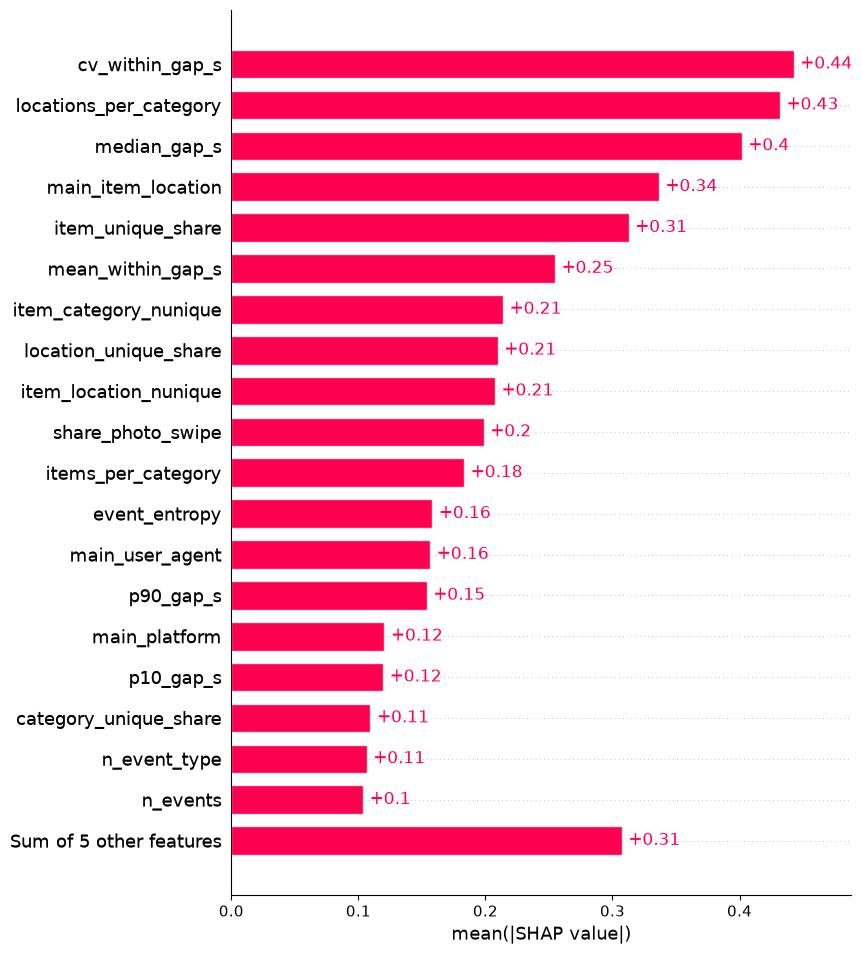

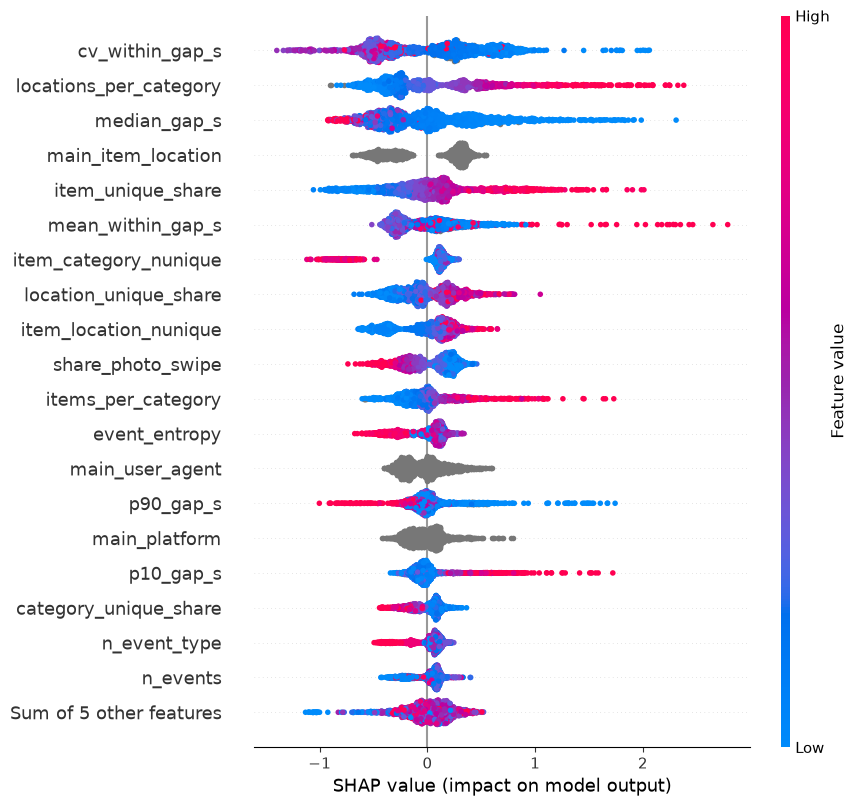

In [53]:
explainer = shap.TreeExplainer(model)
values = explainer(X_valid)
shap.plots.bar(
    values,
    max_display=20
)
shap.plots.beeswarm(
    values,
    max_display=20
)


In [54]:
#Переберём по признакам
ratio_cols = [
    'item_unique_share',
    'location_unique_share',
    'category_unique_share',
    'items_per_location',
    'items_per_category',
    'locations_per_category',
    'locations_per_item'
]

base = event_final_tr.copy()

for col in ratio_cols:
    print("\n", col)

    df_test = base.copy()
    df_test[col] = ratio_tr[col]

    train_catboost(df_test, train, cat_cols=cat_cols)



 item_unique_share
P@R0.7 на валидации: 0.5283
доля ботов (это уровень константы): 0.082

 location_unique_share
P@R0.7 на валидации: 0.5864
доля ботов (это уровень константы): 0.082

 category_unique_share
P@R0.7 на валидации: 0.6043
доля ботов (это уровень константы): 0.082

 items_per_location
P@R0.7 на валидации: 0.5628
доля ботов (это уровень константы): 0.082

 items_per_category
P@R0.7 на валидации: 0.5926
доля ботов (это уровень константы): 0.082

 locations_per_category
P@R0.7 на валидации: 0.5385
доля ботов (это уровень константы): 0.082

 locations_per_item
P@R0.7 на валидации: 0.612
доля ботов (это уровень константы): 0.082


#### **Вывод по блоку:**
<div style="line-height: 1.8;">

Единственным признаком, который улучшил исходный результат, оказался **locations_per_item**. P@R0.7 вырос с 0.6087 до 0.6120. Остальные отношения качество снизили, поэтому в дальнейший набор их не включаем

In [55]:
def add_diversity_ratio_features_2(f):
    
    f = f.copy()
    
    # Насколько число уникальных locations велико относительно items
    f['locations_per_item'] = (
        f['item_location_nunique'] /
        f['item_nunique'].replace(0, np.nan)
    )


    return f

In [56]:
base = add_diversity_ratio_features_2(base)
base.shape

(11091, 19)

## **Функция build_final_table**

<div style="line-height: 1.8;">

На этом этапе существует уже много признаков. Чтобы не путаться, соберём отобранные признаки в одну функцию. Это позволяет использовать одинаковую последовательность преобразований для обеих выборок и дополнительно проверить совпадение состава признаков и уникальность cookie_id.

In [ ]:
def build_final_table(meta, timed, basic, short, technical, content, structure):
    f = timed.merge(
        basic, on="cookie_id", how="left", validate="one_to_one"
    ).merge(
        short, on="cookie_id", how="left", validate="one_to_one"
    )

    f = f[["cookie_id", *base_cols]]

    f = f.merge(
        technical, on="cookie_id", how="left", validate="one_to_one"
    ).merge(
        content, on="cookie_id", how="left", validate="one_to_one"
    )

    f = f.drop(columns=drop_cols).merge(
        structure, on="cookie_id", how="left", validate="one_to_one"
    )

    f = add_diversity_ratio_features_2(f)

    assert f["cookie_id"].equals(meta["cookie_id"])
    return f


base = build_final_table(
    train, time_tr, Xtr, short_gap_tr,
    technical_tr, content_tr, even_structure_tr,
)

base_te = build_final_table(
    test, time_te, Xte, short_gap_te,
    technical_te, content_te, event_struct_te,
)

assert base.columns.equals(base_te.columns)
assert base["cookie_id"].is_unique
assert base_te["cookie_id"].is_unique

print(base.shape, base_te.shape)

(11091, 19) (4909, 19)


In [58]:
cat_cols = [
    "main_item_location",
    "main_platform",
    "main_user_agent",
]

model, X_train, X_valid, y_train, y_valid, p_valid = train_catboost(
    base, train, cat_cols=cat_cols
)

P@R0.7 на валидации: 0.612
доля ботов (это уровень константы): 0.082


_____
## **Эксперимент № 7. Координаты курсора**


<div style="line-height: 1.8;">

Проверим значения координат. Если **pointer_x** и **pointer_y** отражают положение указателя в момент события, это должно описать пространственное разнообразие взаимодействий внутри куки.

Для web-событий посчитаем медиану координат x и y, стандартное отклонение по обеим осям и общее число событий с доступными координатами.

In [71]:
def pointer_geometry_features(ev, meta):
    
    pointer = (
        ev.loc[
            ev["platform_norm"].eq("web")
            & ev["pointer_x"].notna()
            & ev["pointer_y"].notna()
        ]
        .groupby("cookie_id")
        .agg(
            pointer_x_median = ("pointer_x", "median"),
            pointer_y_median = ("pointer_y", 'median'),
            pointer_x_std = ("pointer_x", "std"),
            pointer_y_std = ("pointer_y", "std"),
            n_pointer=("pointer_x", "size"),
        )
    )
    return meta[["cookie_id"]].merge(pointer.reset_index(), on="cookie_id", how="left"
    )


In [72]:
pointer_tr = pointer_geometry_features(ev_tr, train)
pointer_te = pointer_geometry_features(ev_te, test)
pointer_base_tr = base.merge(pointer_tr, on="cookie_id", how="left")
pointer_base_te = base_te.merge(pointer_te, on="cookie_id", how="left")


In [73]:
pointer_result = train_catboost(pointer_base_tr, train, cat_cols=cat_cols)


P@R0.7 на валидации: 0.7517
доля ботов (это уровень константы): 0.082


<div style="line-height: 1.8;">

Добавление геометрии pointer-событий повысило P@R0.7 с **0.6120** до **0.7517**. Это один из наиболее крупных приростов среди проведённых экспериментов. Тем временем, мы улчушили baseline в **6,81 раз**

____
## **Эксперимент №8. Последовательность действий**

<div style="line-height: 1.8;">

До этого большая часть признаков строилась как агрегаты по отдельным событиям. В данном эксперименте добавим характеристики, которые учитывают смысл действий и частично их последовательность.

**repeat_view_share** описывает долю повторных просмотров уже встречавшихся объявлений (более человеческая черта). Для переходов **item_view → item_view**, **search_results_view → item_view** и **item_view → search_results_view** считаем медианное время между событиями. **contact_share** будет показывать долю действий, связанных с контактом с продавцом; **max_search_page** - глубину просмотра поисковой выдачи. Дополнительно используем возраст куки к началу окна наблюдения.

In [65]:
def behavior_features(ev, meta):

    grouped = ev.groupby("cookie_id", sort=False)

    #Просмотры
    views = ev.loc[ev["event_name"].eq("item_view") & ev["item_id"].notna()]
    items = views.groupby("cookie_id")["item_id"]

    previous = grouped["event_name"].shift()
    contact = ev["event_name"].isin(["contact_phone_show", "contact_chat_open", "contact_message_sent" ])

    f = pd.DataFrame({
        "repeat_view_share": 1 - (items.nunique() / items.size()),
        "median_item_to_item_s": ev["gap_s"].where(ev["event_name"].eq("item_view") & previous.eq("item_view")
        ).groupby(ev["cookie_id"]).median(),


        "median_search_to_item_s": ev["gap_s"].where(ev["event_name"].eq("item_view") & previous.eq("search_results_view")
        ).groupby(ev["cookie_id"]).median(),

        "median_item_to_search_s": ev["gap_s"].where(ev["event_name"].eq("search_results_view") & previous.eq("item_view")
        ).groupby(ev["cookie_id"]).median(),

        "contact_share": contact.groupby(ev["cookie_id"]).mean(),

        "max_search_page": ev.loc[ev["event_name"].eq("search_results_view")
        ].groupby("cookie_id")["search_page"].max(),
    })
    
    f.index.name = "cookie_id"
    f = meta[["cookie_id"]].merge(f.reset_index(), on="cookie_id", how="left")
    f["cookie_age_hours"] = (
        meta["window_start_ts"] - meta["cookie_created_at"]
    ).dt.total_seconds().to_numpy() / 3600
    return f[[
        "cookie_id", "cookie_age_hours", "repeat_view_share",
        "median_item_to_item_s", "median_search_to_item_s",
        "median_item_to_search_s", "contact_share", "max_search_page",
    ]]


In [66]:
behavior_tr = behavior_features(ev_tr, train)
behavior_te = behavior_features(ev_te, test)
behavior_base_tr = pointer_base_tr.merge(behavior_tr, on="cookie_id", how="left")
behavior_base_te = pointer_base_te.merge(behavior_te, on="cookie_id", how="left")


In [67]:
behavior_result = train_catboost(behavior_base_tr, train, cat_cols=cat_cols)


P@R0.7 на валидации: 0.837
доля ботов (это уровень константы): 0.082
